In [18]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential

In [19]:
from tensorflow.keras.datasets import reuters
from tensorflow.keras.layers import Dense,GRU,Embedding,Dropout

In [20]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import classification_report, confusion_matrix

In [21]:
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = reuters.load_data(
    num_words=vocab_size
)

In [22]:
len(X_train)

8982

In [23]:
len(X_test)

2246

In [24]:
X_train[0]

[1,
 2,
 2,
 8,
 43,
 10,
 447,
 5,
 25,
 207,
 270,
 5,
 3095,
 111,
 16,
 369,
 186,
 90,
 67,
 7,
 89,
 5,
 19,
 102,
 6,
 19,
 124,
 15,
 90,
 67,
 84,
 22,
 482,
 26,
 7,
 48,
 4,
 49,
 8,
 864,
 39,
 209,
 154,
 6,
 151,
 6,
 83,
 11,
 15,
 22,
 155,
 11,
 15,
 7,
 48,
 9,
 4579,
 1005,
 504,
 6,
 258,
 6,
 272,
 11,
 15,
 22,
 134,
 44,
 11,
 15,
 16,
 8,
 197,
 1245,
 90,
 67,
 52,
 29,
 209,
 30,
 32,
 132,
 6,
 109,
 15,
 17,
 12]

In [25]:
y_train[0]

np.int64(3)

In [26]:
max_length = max(len(sequence) for sequence in X_train)

print(max_length)

2376


In [27]:
#Padding
max_length = 200

X_train = pad_sequences(
    X_train,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    X_test,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

In [28]:
print(X_train.shape)

print(X_test.shape)

(8982, 200)
(2246, 200)


In [29]:
model = Sequential()

model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_length
    )
)

model.add(
    GRU(
        units=128,
        dropout=0.2,
        recurrent_dropout=0.2
    )
)

model.add(Dropout(0.3))

model.add(
    Dense(
        46,
        activation="softmax"
    )
)

In [30]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [33]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=64
)

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 87s 603ms/step - accuracy: 0.3352 - loss: 2.5515 - val_accuracy: 0.3633 - val_loss: 2.3516
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 82s 579ms/step - accuracy: 0.4355 - loss: 2.0824 - val_accuracy: 0.5530 - val_loss: 1.7421
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 81s 575ms/step - accuracy: 0.5790 - loss: 1.6677 - val_accuracy: 0.5971 - val_loss: 1.6136
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 84s 594ms/step - accuracy: 0.6346 - loss: 1.4790 - val_accuracy: 0.6309 - val_loss: 1.4840
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 141s 589ms/step - accuracy: 0.6857 - loss: 1.2915 - val_accuracy: 0.6696 - val_loss: 1.3522
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 81s 573ms/step - accuracy: 0.7237 - loss: 1.1168 - val_accuracy: 0.6852 - val_loss: 1.2710
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 84s 585ms/step - accuracy: 0.7508 - loss: 1.0024 - val_accuracy: 0.7097 - val_loss: 1.2024
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 80s 565ms/step - accuracy: 0.7799 - loss: 

In [34]:
loss, accuracy = model.evaluate(X_test, y_test)

print(f"Test Loss     : {loss:.4f}")
print(f"Test Accuracy : {accuracy:.4f}")

71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.7698 - loss: 1.1855
Test Loss     : 1.1855
Test Accuracy : 0.7698


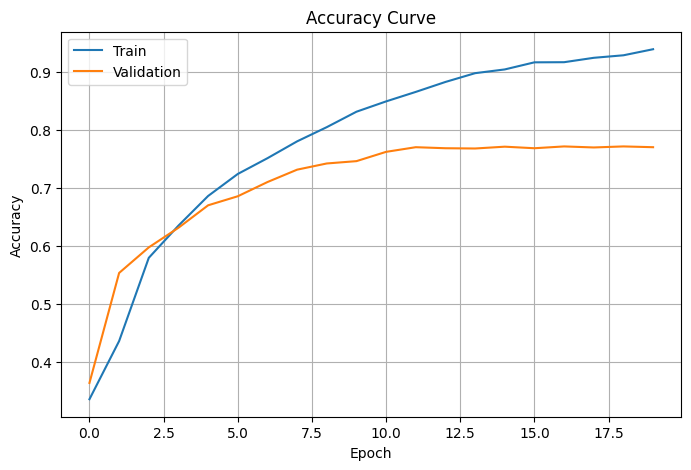

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.grid(True)

plt.show()

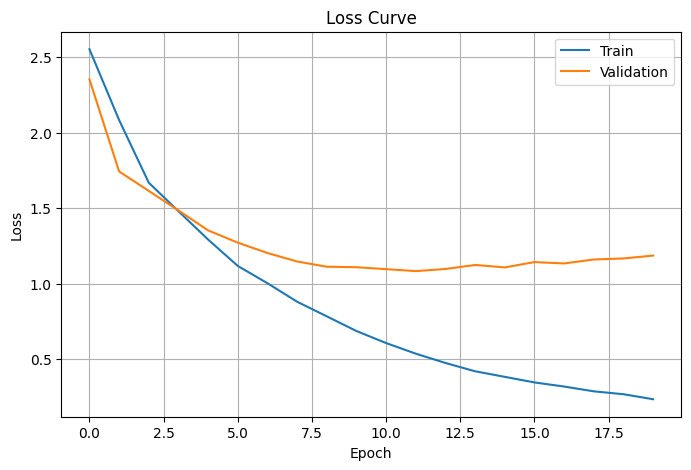

In [36]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.grid(True)

plt.show()

In [37]:
y_pred_prob = model.predict(X_test)

print(y_pred_prob.shape)

71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step
(2246, 46)


In [38]:
import numpy as np

y_pred = np.argmax(y_pred_prob, axis=1)

In [39]:
print("Actual     :", y_test[:20])
print("Predicted  :", y_pred[:20])

Actual     : [ 3 10  1  4  4  3  3  3  3  3  5  4  1  3  1 11 23  3 19  3]
Predicted  : [ 4 10  1 16 13  3  3  3  3  3  1  4  1  3  1 11  3  3 19  3]


In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.58      0.67        12
           1       0.70      0.76      0.73       105
           2       0.68      0.65      0.67        20
           3       0.92      0.92      0.92       813
           4       0.83      0.82      0.82       474
           5       0.00      0.00      0.00         5
           6       0.92      0.79      0.85        14
           7       0.33      0.33      0.33         3
           8       0.64      0.66      0.65        38
           9       0.72      0.84      0.78        25
          10       0.82      0.90      0.86        30
          11       0.57      0.61      0.59        83
          12       0.45      0.38      0.42        13
          13       0.68      0.57      0.62        37
          14       0.00      0.00      0.00         2
          15       0.00      0.00      0.00         9
          16       0.62      0.75      0.68        99
          17       0.25    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [41]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm.shape)

(46, 46)


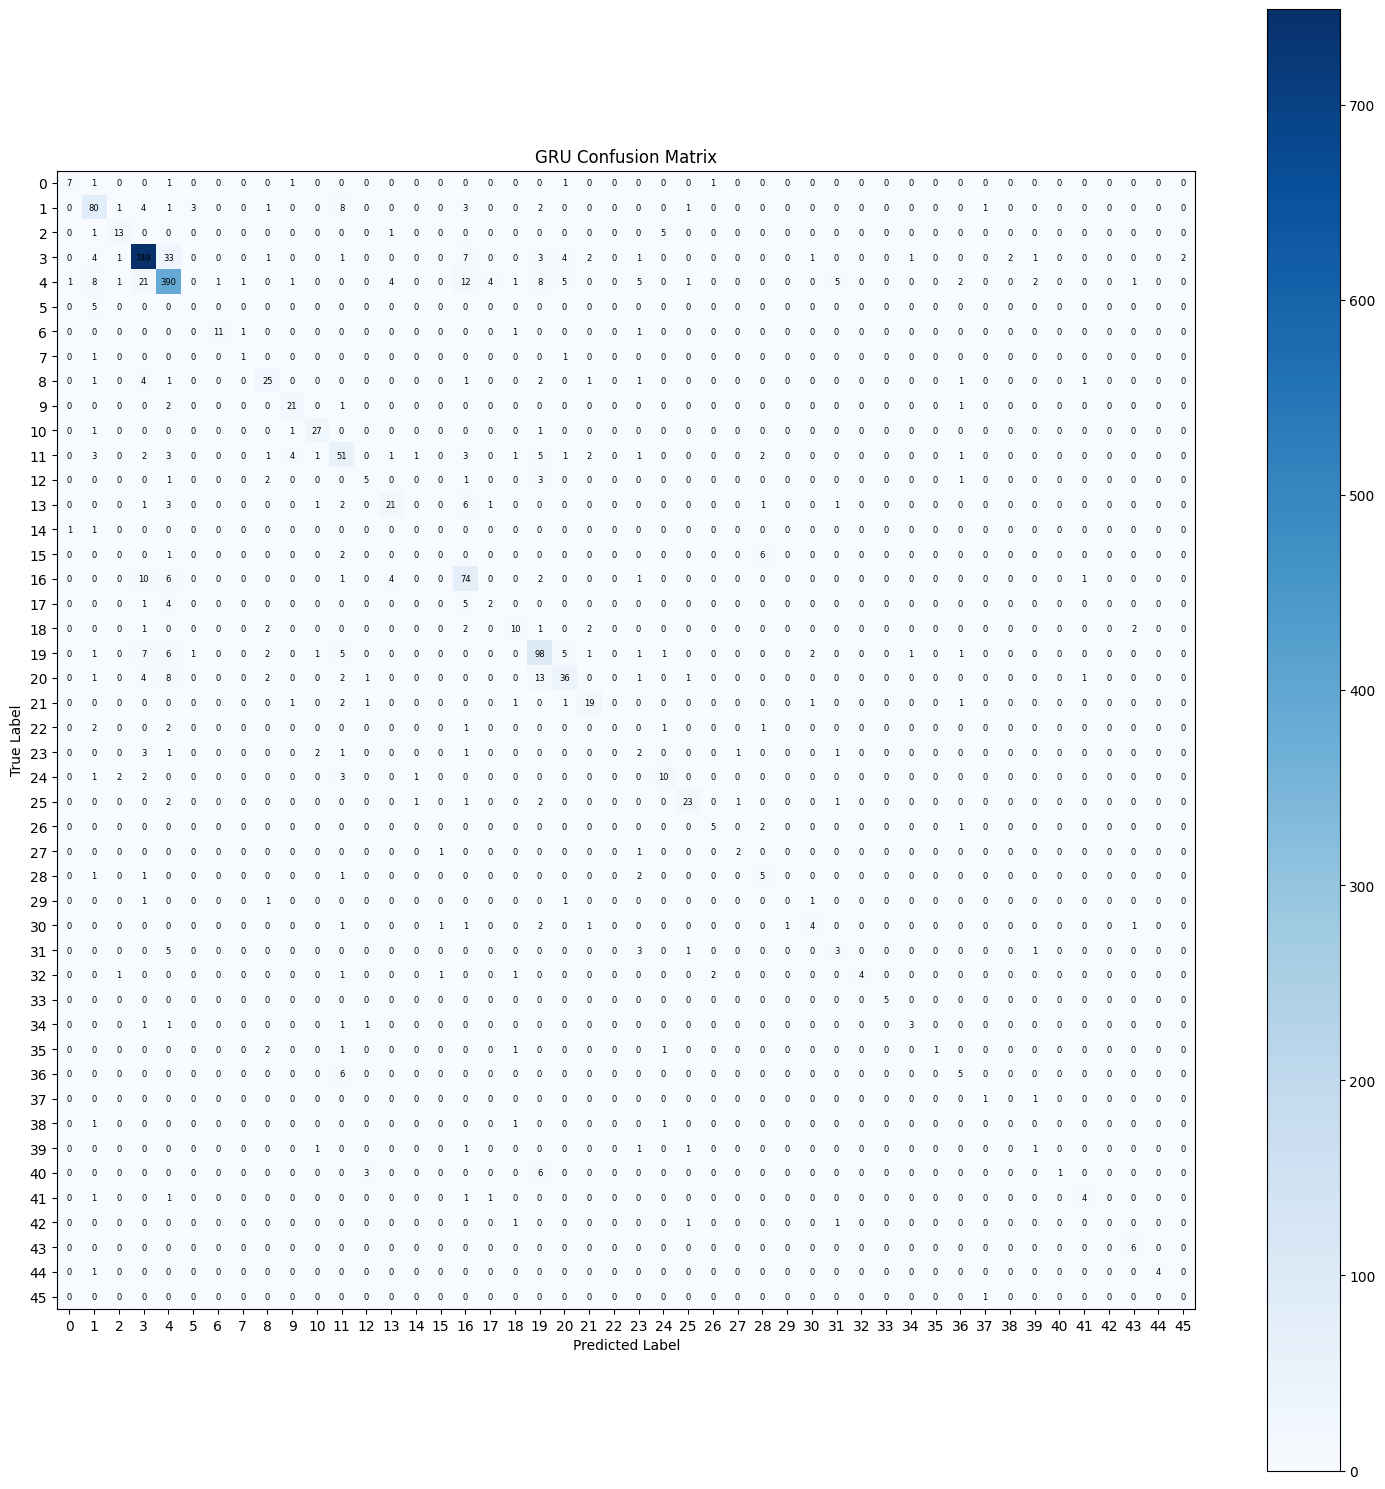

In [43]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(15,15))

plt.imshow(cm, cmap="Blues")

plt.title("GRU Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(np.arange(46))
plt.yticks(np.arange(46))

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=6,
            color="black"
        )

plt.colorbar()

plt.tight_layout()

plt.show()